# 2. Assignment - Medical Image Processing and Machine Learning

### VU 193.215 - 2026 Summer Term

### Information

**Group number:** 06

**Group members:** 
- Emir Softic, 12425770
- Dominik Jakov Gorickic, 52104476
- Jelena Lara Marinkovic, 12451238
- Desislava Nikolova, 12537870

In [ ]:
# this needed to be added for Jelena to be able to run the notebook without errors
import os
import sys

env_prefix = sys.prefix

dll_paths = [
    os.path.join(env_prefix, "Library", "bin"),
    os.path.join(env_prefix, "DLLs"),
    os.path.join(env_prefix, "Lib", "site-packages", "torch", "lib"),
]

for path in reversed(dll_paths):
    if os.path.isdir(path):
        os.environ["PATH"] = path + os.pathsep + os.environ["PATH"]

for path in dll_paths:
    if os.path.isdir(path):
        os.add_dll_directory(path)
        print("Added:", path)

print("Python:", sys.executable)
print("Prefix:", sys.prefix)

import torch
print("Torch:", torch.__version__)

Added: c:\Users\jelen\miniconda3\envs\boneseg-env\Library\bin
Added: c:\Users\jelen\miniconda3\envs\boneseg-env\DLLs
Added: c:\Users\jelen\miniconda3\envs\boneseg-env\Lib\site-packages\torch\lib
Python: c:\Users\jelen\miniconda3\envs\boneseg-env\python.exe
Prefix: c:\Users\jelen\miniconda3\envs\boneseg-env
Torch: 2.4.1+cpu


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from helper_functions import get_data

### Load data used in this exercise

In [4]:
images, masks, landmarks, aligned = get_data()

images: list of 50 images, each as a 2D array with varying sizes
masks: list of 50 contour segmentation masks, each as a 2D array with varying sizes - corresponding to images
landmarks: list of 50 raw landmark coordinates, each as a 2D array of shape (2, n_landmarks)
aligned: np.ndarray of shape (50, 2, 64) containing aligned landmark coordinates for all samples, preprocessed for PCA


# 1. Data Exploration

### 1.1. Plot the first 5 bone images (stored in `images`) and the respective landmarks (stored in `landmarks`) on top.
- Hint: `imshow` and `scatter`

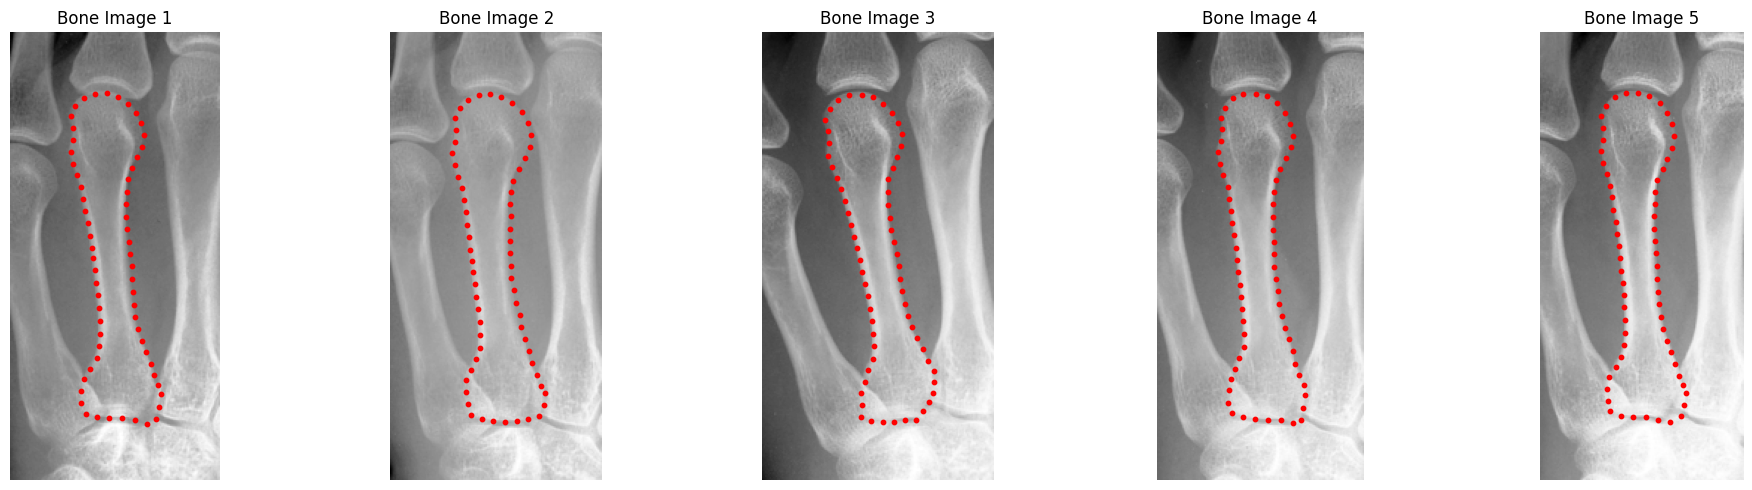

In [5]:
# TODO: Plot the first 5 bone images

# Plot the first 5 images with landmarks overlaid
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i in range(5):
    # Display the bone image
    axes[i].imshow(images[i], cmap='gray')
    
    # Extract landmarks for the current image
    current_landmarks = landmarks[i] 
    x_coords = current_landmarks[0, :]
    y_coords = current_landmarks[1, :]
    
    # Plot landmarks on top of the image
    axes[i].scatter(x_coords, y_coords, c='red', s=10, label='Landmarks' if i == 0 else "")
    axes[i].set_title(f"Bone Image {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 1.2. Plot one set of landmarks together with the corresponding set of aligned landmarks.

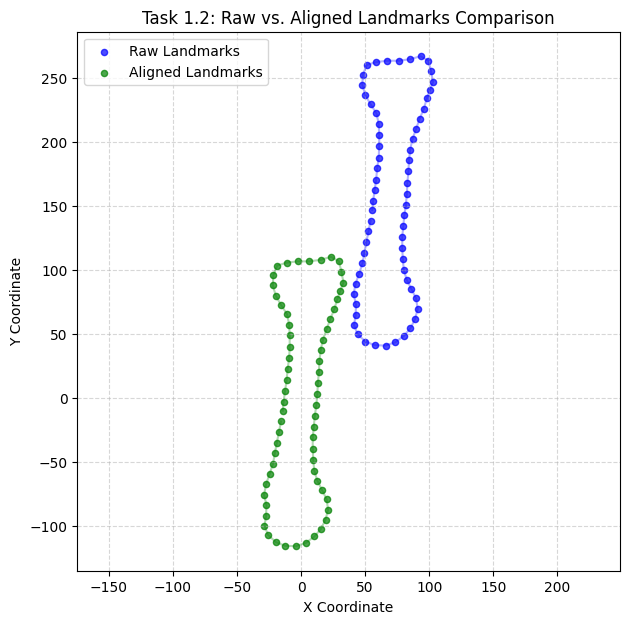

In [6]:
# TODO: Plot one set of landmarks together with the corresponding set of aligned landmarks

# Extract raw and aligned landmarks for the first bone image
raw_lms = landmarks[0]      # Shape: (2, 64)
aligned_lms = aligned[0]    # Shape: (2, 64)

# Slice the X and Y coordinates (Row 0 = X, Row 1 = Y)
x_raw, y_raw = raw_lms[0, :], raw_lms[1, :]
x_alg, y_alg = aligned_lms[0, :], aligned_lms[1, :]

# 3. Plot both shapes
plt.figure(figsize=(7, 7))

# Plot raw landmarks as blue dots
plt.scatter(x_raw, y_raw, c='blue', alpha=0.7, label='Raw Landmarks', s=20)
# Draw a light line connecting them to see the bone contour clearly
plt.plot(x_raw, y_raw, c='blue', alpha=0.3)

# Plot aligned landmarks as green dots
plt.scatter(x_alg, y_alg, c='green', alpha=0.7, label='Aligned Landmarks', s=20)
# Draw a light line connecting them
plt.plot(x_alg, y_alg, c='green', alpha=0.3)

plt.title("Task 1.2: Raw vs. Aligned Landmarks Comparison")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.axis('equal')  # Critical to prevent the hand shape from looking stretched

plt.show()

### 1.3. Extend `generate_shape` so that it allows rotation, scaling and translation of shapes according to the parameters `scaling, rotation, x_t, y_t` and test your function.

- Copy your function `generate_shape` from Assignment 1.
- Add functionality for rotation, scaling and translation (hint: rotation matrix).


In [7]:
def generate_shape(b, eigen_vectors, mean_shape, scaling, rotation, x_t, y_t):
    """
    Generate a 2D shape instance from PCA parameters and an affine transform.

    Parameters
    ----------
    b : ndarray
        PCA weight coefficients (length <= n_components).
    eigen_vectors : ndarray
        PCA principal axes with shape (2N, n_components).
    mean_shape : ndarray
        Mean-shape vector of length 2N.
    scaling : float
        Scaling factor.
    rotation : float
        Rotation angle in degrees.
    x_t : float
        Translation offset in the x-direction.
    y_t : float
        Translation offset in the y-direction.

    Returns
    -------
    new_shape : ndarray
        Transformed shape coordinates in the format [x1, ..., xN, y1, ..., yN].
    """

    # TODO: Generate the shape from the PCA parameters
    # (x = mean + P * b)
    shape_pca = mean_shape + np.dot(eigen_vectors, b)

    # To apply rotation cleanly, we split the flat 2N vector into X and Y groups
    N = len(shape_pca) // 2
    x_coords = shape_pca[:N]
    y_coords = shape_pca[N:]

    # TODO Scale the shape
    x_scaled = x_coords * scaling
    y_scaled = y_coords * scaling

    # TODO Calculate the rotation angle in radians
    rad = np.radians(rotation)

    # TODO Create the transformation matrix
    # Since we can just perform the matrix multiplication directly on coordinates:
    # x_rot = x * cos(theta) - y * sin(theta)
    # y_rot = x * sin(theta) + y * cos(theta)
    cos_a = np.cos(rad)
    sin_a = np.sin(rad)
    
    # TODO Transform the shape using the transformation matrix
    x_new = (x_scaled * cos_a) - (y_scaled * sin_a) + x_t
    y_new = (x_scaled * sin_a) + (y_scaled * cos_a) + y_t
    # Re-flatten back into the required output format [x1,...,xN, y1,...,yN]
    new_shape = np.concatenate([x_new, y_new])

    return new_shape

### 1.4. Test your adapted function `generate_shape`.

- Perform PCA on the first 30 landmark sets in `aligned` with a reasonable number of components (required data shape: (30, 128)). You may use the function `PCA` from `sklearn`.
- Use your group number assigned in TUWEL for parameterizing the following transformations:
    - rotate by **90 + 2 * [group_number] degrees**
    - translate by **90 + [group_number] pixels** in x direction and **-50 pixels** in y direction
    - scale by a factor of **1.5**
    - use a PCA weight vector of your choice
- Apply the transformation and plot the shape and the mean_shape using `plot_shape`

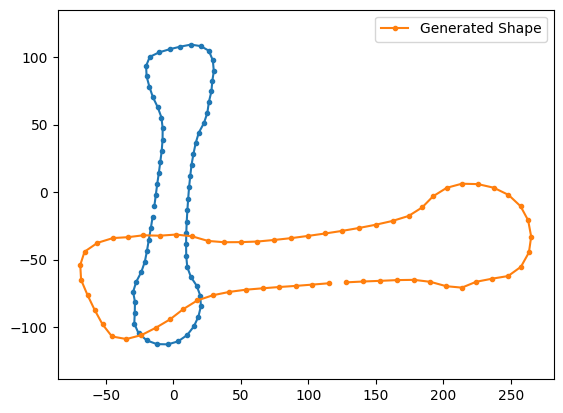

In [ ]:
from helper_functions import plot_shape
from sklearn.decomposition import PCA

data = np.stack([lm.flatten() for lm in aligned[:30]])  # shape (30,128)

n_comp = 5

# TODO: Perform PCA on the data and get the eigen vectors, eigen values, and mean shape
pca = PCA(n_components=n_comp)
pca.fit(data)

eigen_vectors = pca.components_.T  # Shape: (128, n_comp)
eigen_values = pca.explained_variance_
mean_shape = pca.mean_

# PCA weight vector (zeros uses mean shape)
b = np.zeros(n_comp) # TODO: choose b

# Affine transform parameters for testing
scaling = 1.5  # Scale the bone by a factor 1.5 # TODO: set scaling
rotation = 102  # rotate by (90 + 2 * 6) degrees # TODO: set roation
x_t, y_t = 96, -50  # move + (90 + 6) pixels in x direction and -50 in y direction # TODO: set x and y translation

# TODO: Generate the shape
new_shape = generate_shape(b, eigen_vectors, mean_shape, scaling, rotation, x_t, y_t)

# Plot the generated and mean shapes
plot_shape(new_shape, mean_shape)

# 2. Feature Extraction and Edge Detection via Convolutions

### 2.1. Edge Detection via Convolutions
#### (a) Kernels
Create 2 edge detection kernels (image filters) represented as matrices (Fx, Fy) of dimension `[i,j]` where `i` and `j` are 3. We will focus on the filters called Prewitt Operator. These have the aim to identify edges in images by focusing on detecting changes in intensity levels. You should implement a horizontal and vertical edge detection filter. You may also create additional kernels for edge detection, if you want to experiment with these.


In [9]:
# TODO Define PREWITT kernels for X and Y
PREWITT_X = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
PREWITT_Y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])


#### (b) Convolution operation
- Implement the convolution operation on your own as function `conv2d` with input parameters `image` representing a 2D image of size [m, n] and `kernel` representing a `3x3` filter kernel.
- The output should be the convolved image of size [m,n]. For convolving the kerning at the image boundaries image padding with 0 values should be used.

In [10]:
def conv2d(image, kernel):
    """
    Convolve a 2D image with a 3×3 kernel, preserving input size.

    Parameters
    ----------
    image : ndarray
        2D input image array.
    kernel : ndarray
        2D convolution kernel of shape (3, 3).

    Returns
    -------
    output : ndarray
        2D array of the same shape as the input image.
    """

    # TODO: Initialize output array
    output = np.zeros(image.shape, dtype=float)

    # TODO: add padding to preserve input size
    image_w_pad = np.pad(image, pad_width=1, mode='constant') #adds 1 row/column of 0s on each side

    # TODO: Loop over the image and apply the kernel
    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            region = image_w_pad[row:row + 3, col:col + 3]
            output[row, col] = np.sum(region*kernel)

    return output

#### (c) Test your convolution operation
- Select 3 random bone images from `images` and convolve each of them with the filters you created.
- Visualize the resulting images using `plot_convolutions`.

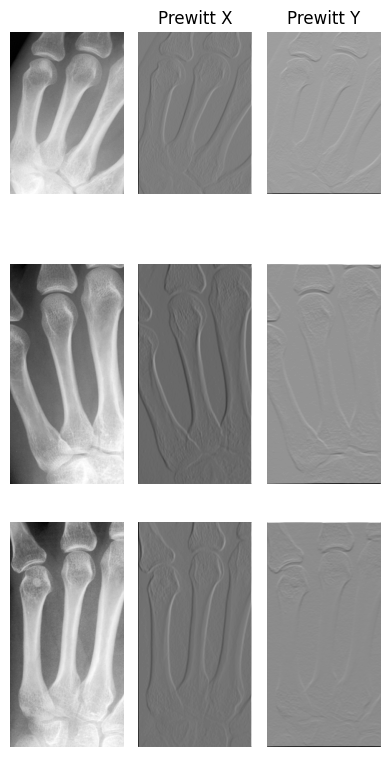

In [11]:
from helper_functions import plot_convolutions
import random

random.seed(10) # added seed for reproducibility when sampling images

kernels = {
    'Prewitt X': PREWITT_X,
    'Prewitt Y': PREWITT_Y,
}

originals = random.sample(images, 3)# TODO: select 3 images
convolved = []
for i in originals:
    conv = [conv2d(i, kernel) for kernel in kernels.values()]
    convolved.append(conv)

plot_convolutions(originals, convolved, kernels)

### 2.2. Image Feature Computation
- Implement `compute_features(image)` which returns a feature matrix of size `[nfeatures, npixels]` of an image, including the following features:
    - Grey value of an image
    - Gradient in x- and y-direction (using the kernels you created)
    - Magnitude of the gradient
    - x- and y-coordinates of the pixels (hint: `np.meshgrid`)
- Feel free to implement and evaluate other additional features. You are free to use libraries such as `skimage` (e.g. from [features](https://scikit-image.org/docs/0.25.x/api/skimage.feature.html) or [filters](https://scikit-image.org/docs/0.25.x/api/skimage.filters.html)).
- Visualize the features for the first image in `images`.

Note: some features may be computationally expensive, so the results of `compute_features` can be cached. If you wish to not use this feature, you can remove the annotation (`@memory.cache`). In case you change your implementation of `compute_features`, do not forget to delete the directory `cache_dir` to clear the cache.

In [12]:
from joblib import Memory
cache_dir = os.path.join(os.getcwd(), 'cache_dir')
memory = Memory(location=cache_dir, verbose=0)

In [13]:
from skimage.feature import canny

@memory.cache
def compute_features(image):
    """
    Extract features from a 2D grayscale image.

    Parameters
    ----------
    image : np.ndarray
        A 2D NumPy array of shape (H, W), representing a grayscale image.

    Returns
    -------
    features : np.ndarray
        A 2D array of shape (F, N), where:
        - F is the number of extracted features,
        - N is the number of pixels (H × W).
    """

    
    H, W = image.shape

    # TODO: get the grayscale values
    grey = image.flatten()

    # TODO: get convolution results for X and Y
    edge_x = conv2d(image, PREWITT_X).flatten()
    edge_y = conv2d(image, PREWITT_Y).flatten()

    # TODO: get the magnitude values of the convolution results
    gmag_x = np.abs(edge_x)
    gmag_y = np.abs(edge_y)
    gmag = np.sqrt(edge_x**2 + edge_y**2)
    
    # TODO: get X and Y coordinates of the pixels
    x_grid, y_grid = np.meshgrid(np.arange(W), np.arange(H))
    x_coords = x_grid.flatten()
    y_coords = y_grid.flatten()

    # OPTIONAL TODO: add additional features (e.g.: canny, sobel)

    features = np.vstack([
        grey,
        edge_x, edge_y,
        gmag_x, gmag_y,
        gmag,
        x_coords, y_coords,
    ])

    return features

#### Visualize Features

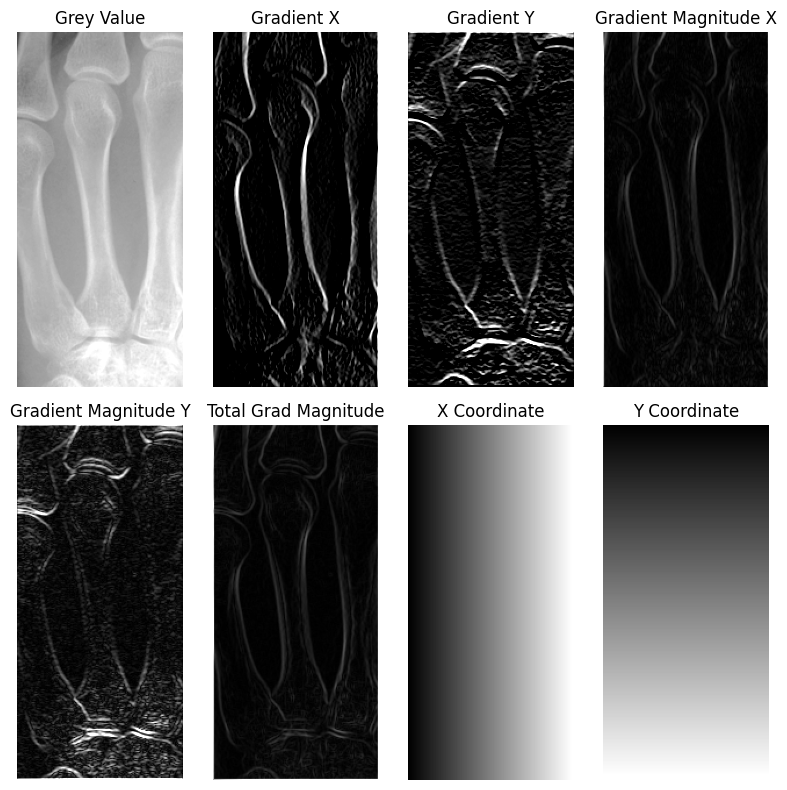

In [14]:
test_image = images[0]
H, W = test_image.shape
features_test = compute_features(test_image)

# TODO: get titles and features for plotting
titles = [
    "Grey Value",
    "Gradient X",
    "Gradient Y",
    "Gradient Magnitude X",
    "Gradient Magnitude Y",
    "Total Grad Magnitude",
    "X Coordinate",
    "Y Coordinate"
]
feats = [feature.reshape(H, W) for feature in features_test]

fig, axes = plt.subplots(2, 4, figsize=(8, 8))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(feats):
        ax.imshow(feats[idx], cmap='gray', vmin=0, vmax=np.percentile(feats[idx], 99))
        ax.set_title(titles[idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

# 3. Classification and Feature Selection
In this task we investigate how image features are selected to train a classifier to solve a binary classification task - the detection of edges (bone contours) in an image.

The classification result provides per image pixel a label, where 1 denotes an edge  and 0 background/no edge. In total in this tasks we will compare and explore three bone contour extraction methods: (1) Random Forest, (2) a U-Net based Deep Learning framework and (3) Particle Filters using a defined training and testing set.


### 3.1. Data Preparation
- Split the image set of 50 images and the corresponding masks into a training set of 30 images (`I_train`) and masks (`y_train`) and a test set of 20 images (`I_test`) and corresponding masks (`y_test`).
- Compute the features of all images and store them in `X_train` and `X_test`, respectively.

In [15]:
I_train = images[:30]
y_train = masks[:30]
I_test = images[30:]
y_test = masks[30:]

### 3.2. Random Forest (RF)
- Implement the function `train_rf` which takes a list of feature arrays and labels (masks) and trains a Random Forest classifier and returns the trained classifier.
- Implement the function `predict_segmentation_rf` which takes a trained Random Forest classifier and an image and returns a predicted segmentation.

#### (a) Define a Random Forest Classifier
- Use the `RandomForestClassifier` from `sklearn`.
- Get familiar with the parameters and select suitable ones for training.
- The RF classifier should be trained on **extracted image features** and not the images directly. Thus, compute image features for all input images in `I_train` and `I_test` and store the resulting features in `X_train` and `X_test`.
- **Hint**: to speed up the training process you should use all pixels of the bone contours but only a randomly sampled subset of the background pixels (equal amount of fore- (bone contours) and background (non-bone contours)).

In [16]:
X_train = [compute_features(img) for img in I_train]
X_test = [compute_features(img) for img in I_test]

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
def train_rf(features, labels, n_trees=100, random_state=0):
    """
    Train a Random Forest classifier with class balancing via undersampling.

    This function concatenates feature and label arrays, balances the classes
    by undersampling the majority class (negative class), and trains a
    Random Forest classifier.

    Parameters
    ----------
    features : list of np.ndarray
        List of feature arrays to be horizontally stacked. Each array should
        have shape (F, N), where F is the number of features and N is the number of samples.
    labels : list of np.ndarray
        List of label arrays (same shape as image masks). Non-zero values are treated as positive class.
    n_trees : int, optional
        Number of trees in the Random Forest (default is 100).
    random_state : int, optional
        Seed for reproducibility (default is 0).

    Returns
    -------
    clf : RandomForestClassifier
        Trained Random Forest classifier with out-of-bag (OOB) score enabled.
    """

    # TODO get features and labels and train RandomForestClassifier
    X = np.hstack(features).T
    y = np.concatenate([m.flatten() for m in labels])
    rng = np.random.default_rng(random_state)
    pos = np.where(y > 0)[0]
    neg = rng.choice(np.where(y == 0)[0], size=len(pos), replace=False)
    idx = np.concatenate([pos, neg])

    clf = RandomForestClassifier(
        n_estimators=n_trees,
        oob_score=True,
        random_state=random_state,
        n_jobs=-1
    )
    clf.fit(X[idx], y[idx])

    return clf

#### (b) Train the classifier
- Use the image features  `X_train` as input to train a Random Forest classifier and the corresponding image masks `y_train` as class labels.

In [19]:
rf_clf = train_rf(X_train, y_train)# TODO: train Random Forest classifier

#### (c) Predict segmentations
- Implement the function `predict_segmentation_rf` which takes the Random Forest classifier as well as an image and returns the prediction from the classifier.
- Visualize the prediction of the first test image (from `I_test`) and compare it to the corresponding target label from `y_test`.

In [20]:
def predict_segmentation_rf(clf, image):
    '''
    clf: Trained Random Forest classifier
    image: 2D grayscale image for segmentation prediction

    returns:
    segmentation: 2D array with predicted segmentation mask
    '''
    
    # TODO Predict segmentation using the trained Random Forest classifier
    H, W = image.shape
    segmentation = clf.predict(compute_features(image).T).reshape(H, W)

    return segmentation

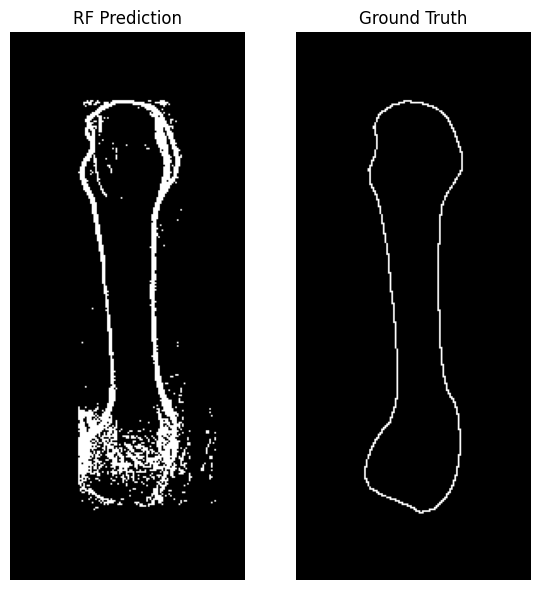

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 6))

# TODO: visualize the predicted segmentation and the ground truth mask

ax1.imshow(predict_segmentation_rf(rf_clf, I_test[0]), cmap='gray')
ax1.set_title('RF Prediction')
ax1.axis('off')

ax2.imshow(y_test[0], cmap='gray')
ax2.set_title('Ground Truth')
ax2.axis('off')

plt.tight_layout()
plt.show()

#### (d) Predict all bone contours
- Use the trained classifier and predict bone contours for the feature test set `X_test` and store the predictions in `y_pred_RF`.
- Compare the bone contour predictions to the target labels `y_test` using the helper function `evaluate_binary_segmentation` to get Dice Score, Precision and Recall.

In [22]:
y_pred_RF = [predict_segmentation_rf(rf_clf, img) for img in I_test] # TODO: predict_segmentation_rf(rf_clf, I_test[0])

In [23]:
from helper_functions import plot_prediction_triplets, show_feature_importance, evaluate_binary_segmentation

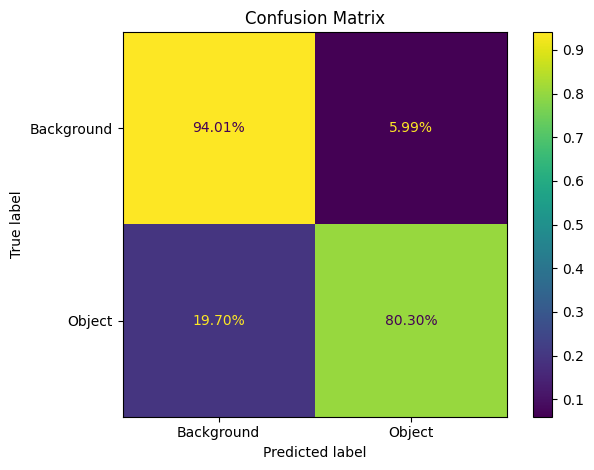

Dice Score: 0.24926794870262584
Precision: 0.14753402563594692
Recall: 0.8029568029568029


In [24]:
results = evaluate_binary_segmentation(y_pred_RF, y_test)
print("Dice Score:", results['dice'])
print("Precision:", results['precision'])
print("Recall:", results['recall'])

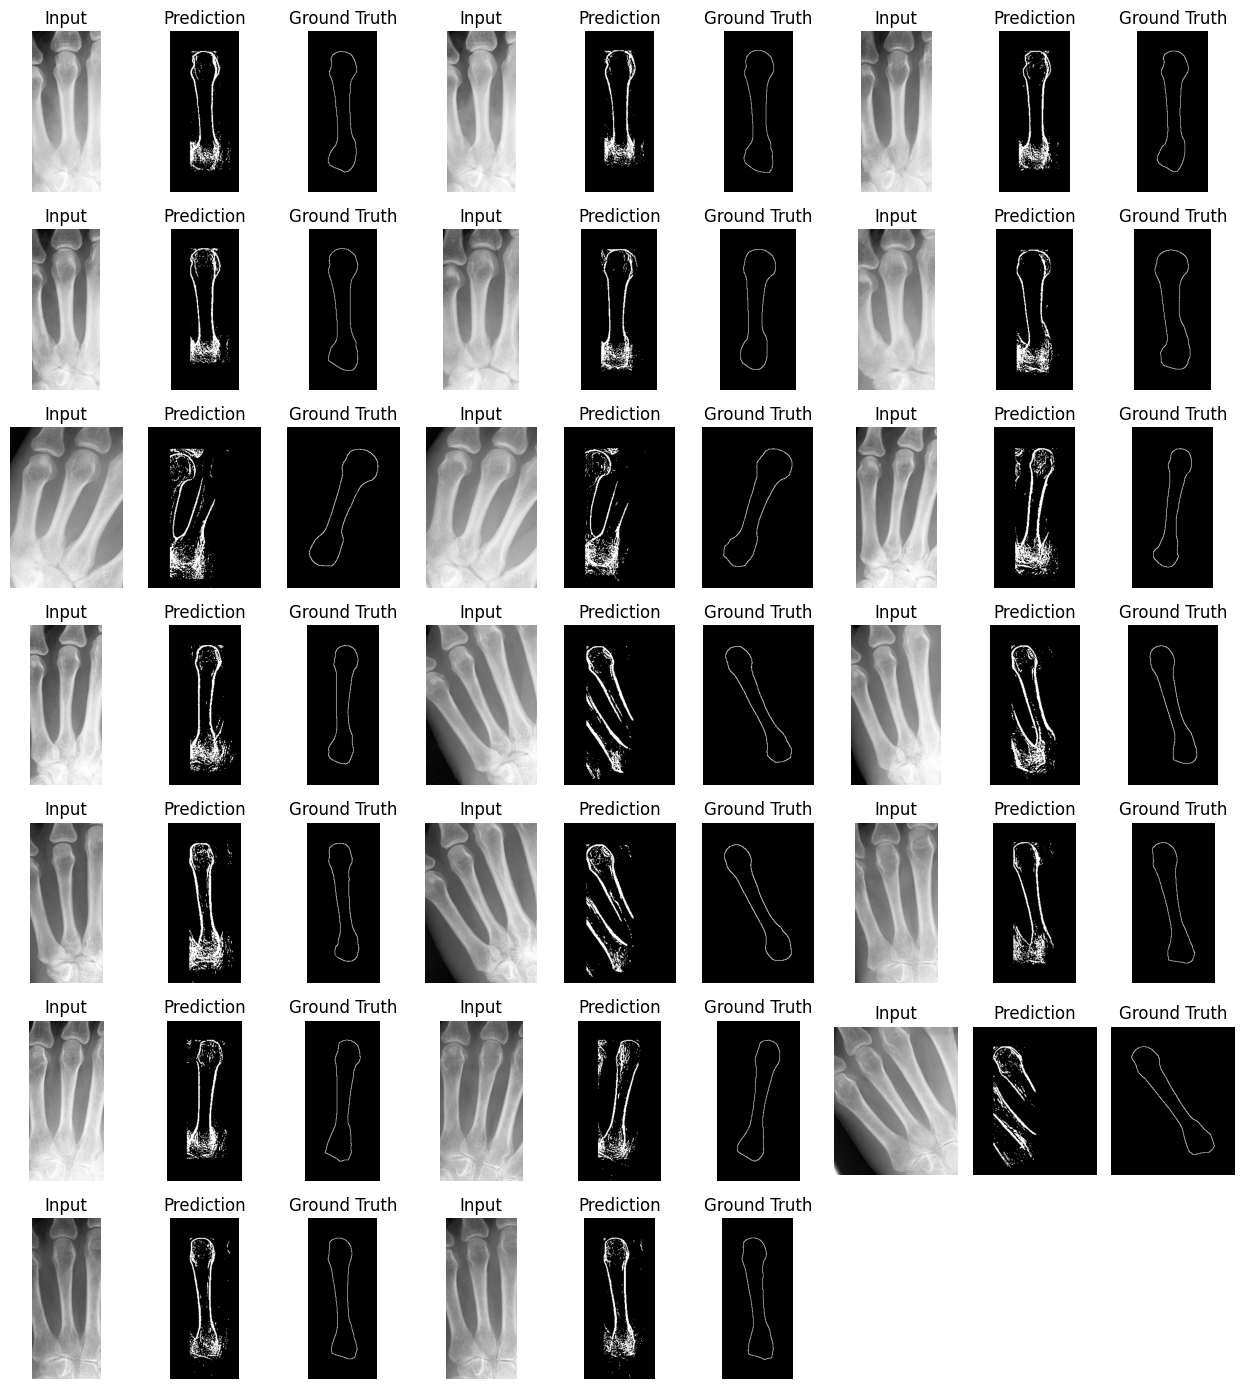

In [25]:
plot_prediction_triplets(I_test, y_pred_RF, y_test)

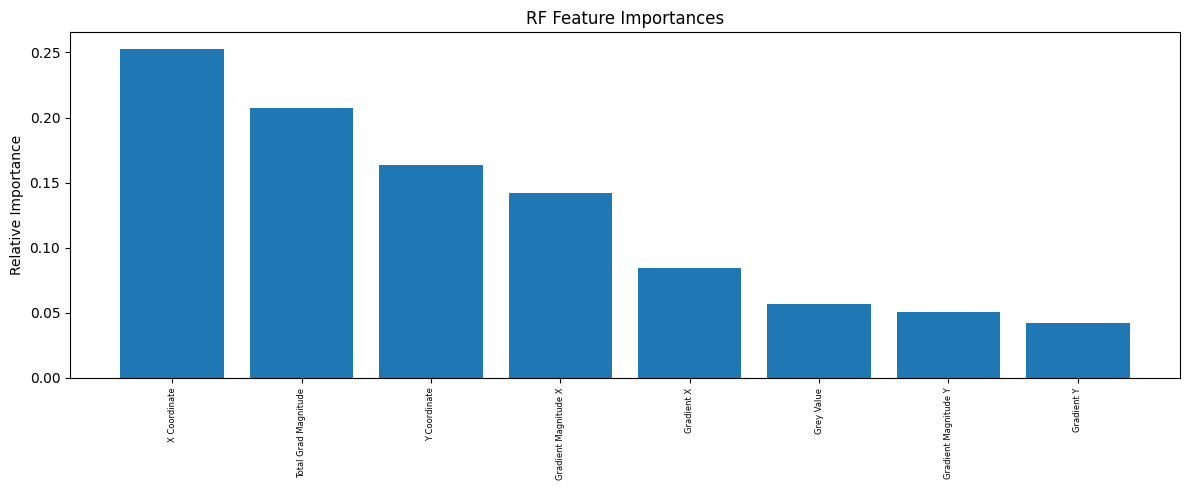

In [26]:
show_feature_importance(rf_clf, titles)

To be able to solve the Task 3.5.3., additional Random Forest models need to be trained. We'll do it it in the following part of the notebook.

In [85]:
import pandas as pd
import matplotlib.pyplot as plt


# Feature indices correspond to the order in compute_features()
feature_configurations = {
    "All features": [
        0, 1, 2, 3, 4, 5, 6, 7
    ],

    "Without coordinates": [
        0, 1, 2, 3, 4, 5
    ],

    "Without gradients": [
        0, 6, 7
    ],

    "Without grey value": [
        1, 2, 3, 4, 5, 6, 7
    ],

    "Gradient features only": [
        1, 2, 3, 4, 5
    ],

    "Coordinates only": [
        6, 7
    ],

}

In [ ]:
ablation_models = {}
ablation_predictions = {}
ablation_results = []


for configuration_name, feature_indices in feature_configurations.items():

    print(f"Evaluating: {configuration_name}")

    if configuration_name == "All features":
        classifier = rf_clf
        predictions = y_pred_RF

    else:
        selected_X_train = [
            features[feature_indices, :]
            for features in X_train
        ]

        classifier = train_rf(
            selected_X_train,
            y_train,
            n_trees=100,
            random_state=0,
        )

        predictions = []

        for image, features in zip(I_test, X_test):

            selected_X_test = features[feature_indices, :]

            prediction = classifier.predict(
                selected_X_test.T
            ).reshape(image.shape)

            predictions.append(prediction)

    metrics = evaluate_binary_segmentation(
        predictions,
        y_test,
        show_confusion_matrix=False,
    )

    ablation_models[configuration_name] = classifier
    ablation_predictions[configuration_name] = predictions

    ablation_results.append({
        "Feature configuration": configuration_name,
        "Number of features": len(feature_indices),
        "Dice": metrics["dice"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "OOB score": classifier.oob_score_,
    })

Evaluating: All features
Evaluating: Without coordinates
Evaluating: Without gradients
Evaluating: Without grey value
Evaluating: Gradient features only
Evaluating: Coordinates only


In [87]:
ablation_results_df = pd.DataFrame(ablation_results)

baseline = ablation_results_df.loc[
    ablation_results_df["Feature configuration"] == "All features"
].iloc[0]

for metric in ["Dice", "Precision", "Recall"]:
    ablation_results_df[f"{metric} change"] = (
        ablation_results_df[metric]
        - baseline[metric]
    )

ablation_results_df = ablation_results_df.sort_values(
    by="Dice",
    ascending=False,
).reset_index(drop=True)

display(ablation_results_df.round(4))

,Feature configuration,Number of features,Dice,Precision,Recall,OOB score,Dice change,Precision change,Recall change
0,All features,8,0.2493,0.1475,0.8030,0.9401,0.0000,0.0000,0.0000
1,Without grey value,7,0.2221,0.1290,0.7993,0.9346,-0.0272,-0.0186,-0.0037
2,Without gradients,3,0.0964,0.0524,0.5984,0.8968,-0.1529,-0.0951,-0.2045
3,Gradient features only,5,0.0882,0.0467,0.7906,0.7783,-0.1610,-0.1008,-0.0124
4,Without coordinates,6,0.0877,0.0464,0.8113,0.7944,-0.1615,-0.1012,0.0083
5,Coordinates only,2,0.0832,0.0449,0.5636,0.8494,-0.1661,-0.1026,-0.2393


In [90]:
# Rank all evaluated models by Dice score in descending order
ranked_models = (
    ablation_results_df[
        [
            "Feature configuration",
            "Dice",
            "Precision",
            "Recall",
        ]
    ]
    .sort_values(by="Dice", ascending=False)
    .reset_index(drop=True)
)

ranked_models.insert(
    0,
    "Rank",
    range(1, len(ranked_models) + 1),
)

display(ranked_models.round(4))
print(ranked_models.round(4).to_string(index=False))

,Rank,Feature configuration,Dice,Precision,Recall
0,1,All features,0.2493,0.1475,0.8030
1,2,Without grey value,0.2221,0.1290,0.7993
2,3,Without gradients,0.0964,0.0524,0.5984
3,4,Gradient features only,0.0882,0.0467,0.7906
4,5,Without coordinates,0.0877,0.0464,0.8113
5,6,Coordinates only,0.0832,0.0449,0.5636


 Rank  Feature configuration   Dice  Precision  Recall
    1           All features 0.2493     0.1475  0.8030
    2     Without grey value 0.2221     0.1290  0.7993
    3      Without gradients 0.0964     0.0524  0.5984
    4 Gradient features only 0.0882     0.0467  0.7906
    5    Without coordinates 0.0877     0.0464  0.8113
    6       Coordinates only 0.0832     0.0449  0.5636


### 3.3. U-Net
In this task you will compare your results from the Random Forest segmentation to those from a U-Net. You will train two networks – one with data augmentation and one without. Feel free to tweak any hyperparameters if needed.
Then, you will evaluate the results and compare them to the Random Forest.

(Network details: the given convolutional neural network (CNN) is a U-Net ([paper](https://arxiv.org/pdf/1505.04597)) combined with a ResNet-34 backbone ([paper](https://arxiv.org/pdf/1512.03385)). It is lightweight and should be able to run about 100 epochs in less than 10 minutes even when only using a CPU. Unlike a regular ResNet, the residual connections are made on upsampling, where regular U-Nets would have concatenations. The `train_unet_model` function takes in all images and masks and splits them 30-10-10 into training, validation and testing. The model with the smallest validation loss will be returned. Note that every time the model has a new "best model", it saves the checkpoint in the `checkpoints` directory. These checkpoints are not deleted automatically and may start to take up considerable storage space when training multiple times.)

#### (a) Train two networks
 Train the networks `y_pred_UNet1` and `y_pred_UNet2`. The code is already given and when run, `train_unet_model` will plot training and validation loss after training. 

If you want, you can tweak the learning rate and the number of epochs for training using the parameters `lr` and `n_epochs`. Should you have troubles with a cuda device or mps, simply use the `device_override` parameter to use a different device, e.g. `device_override='cpu'`.

In [27]:
from training import train_unet_model

c:\Users\jelen\miniconda3\envs\boneseg-env\lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info [ASN1: NOT_ENOUGH_DATA] not enough data (_ssl.c:4192)
  data = fetch_version_info()


Using device: cpu


Training Progress: 100%|██████████| 100/100 [14:43<00:00,  8.84s/epoch, train_loss=0.0796, val_loss=0.361]


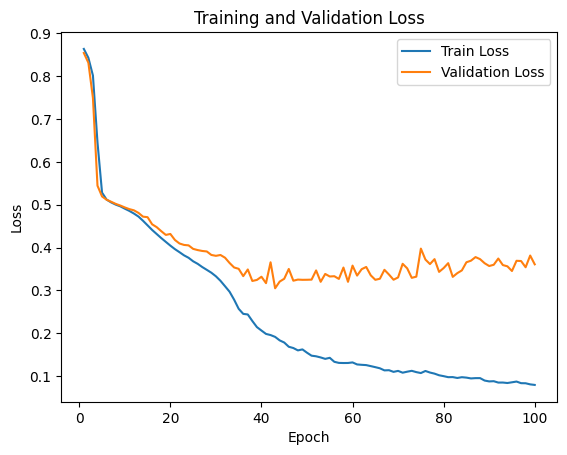

c:\Users\jelen\Desktop\Medical_Assignment_2\boneseg_MedImageML_ass2\training.py:232: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt_path, ma

Best checkpoint was: ../Musterlösung/checkpoints\best_epoch42_valloss0.3051.pth with val_loss=0.3051. Loading checkpoint...
Test Loss: 0.3331


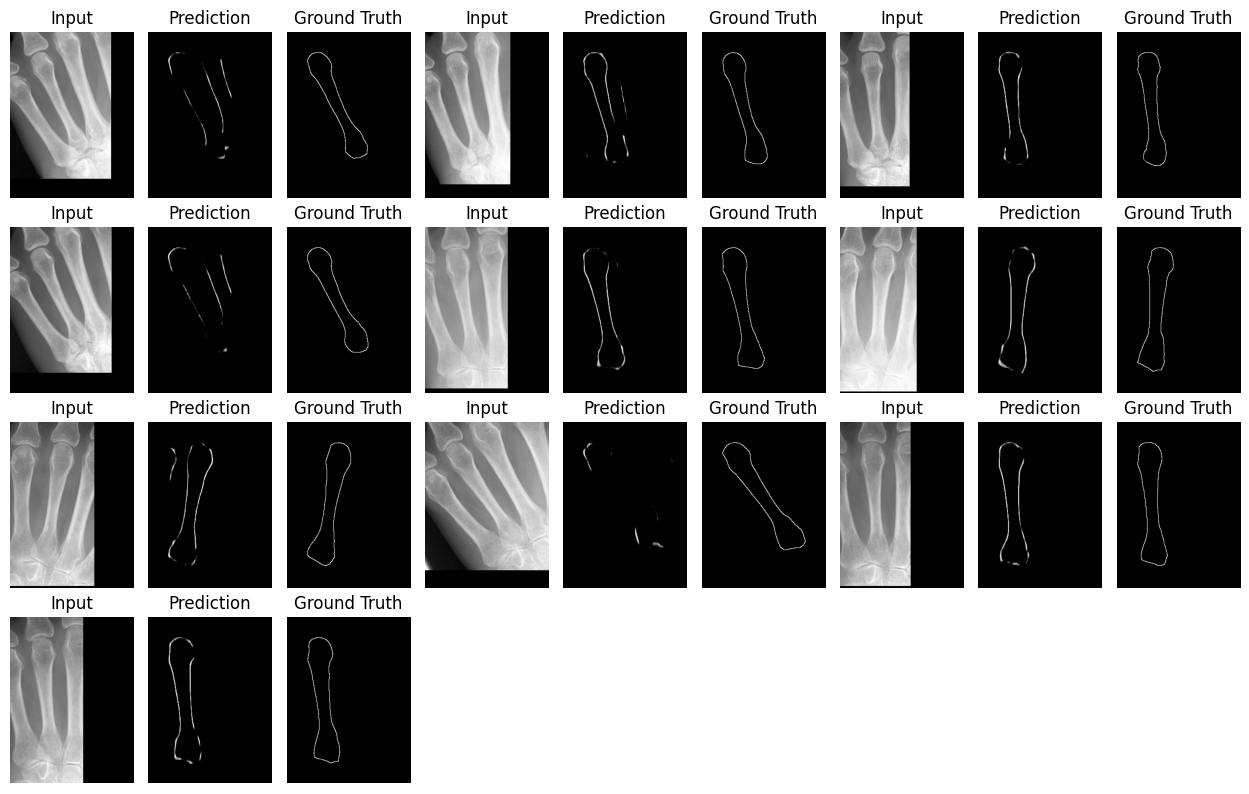

In [28]:
y_pred_UNet1 = train_unet_model(images, masks, augment=False, lr=1e-4)

Using device: cpu


Training Progress: 100%|██████████| 100/100 [15:00<00:00,  9.00s/epoch, train_loss=0.289, val_loss=0.324]


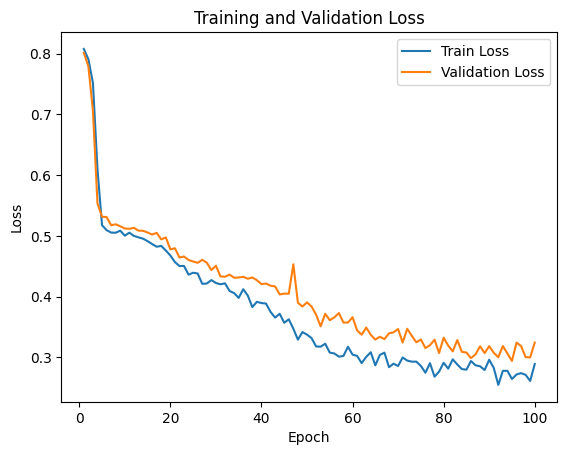

Best checkpoint was: ../Musterlösung/checkpoints\best_epoch94_valloss0.2941.pth with val_loss=0.2941. Loading checkpoint...
Test Loss: 0.2949


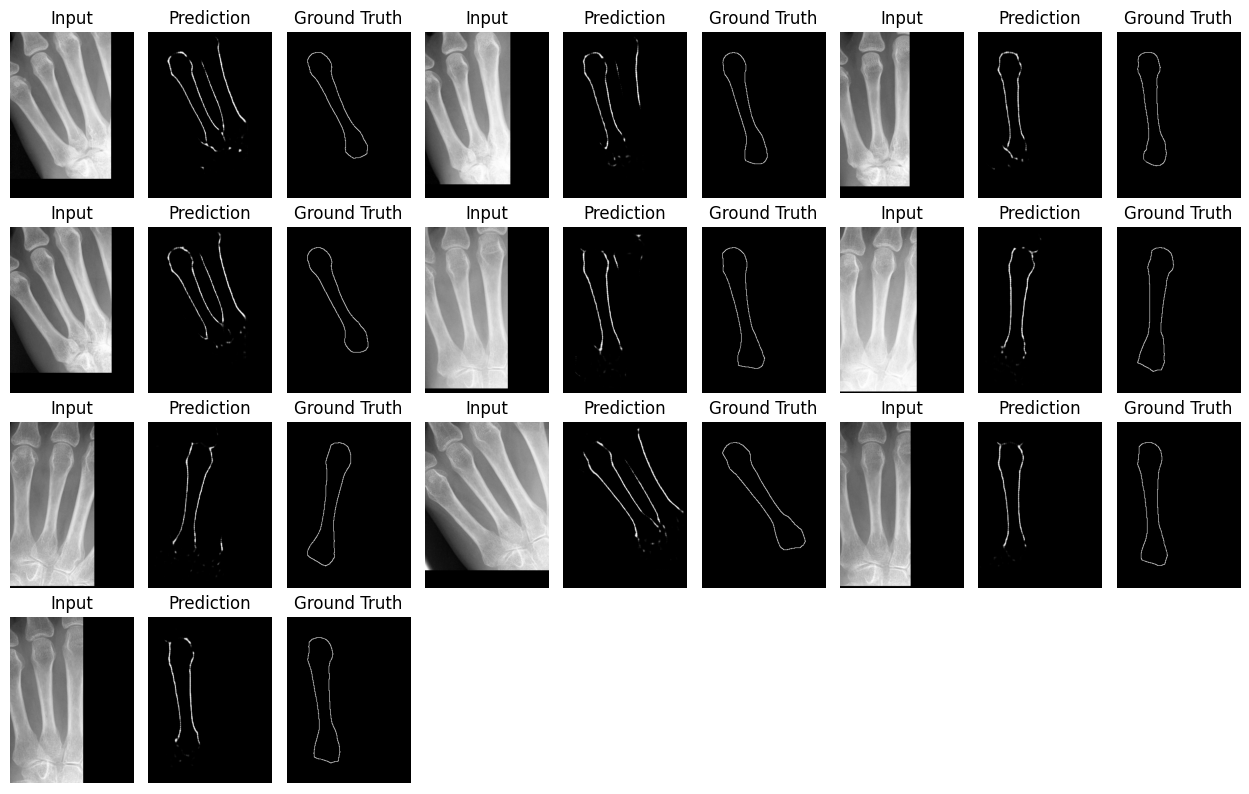

In [29]:
y_pred_UNet2 = train_unet_model(images, masks, augment=True, lr=1e-4)

#### (b) Interpret filters
Instead of using a predefined set of filters (as we used in Task 2.1 for edge detection),  a convolutional neural network – learns the filter weights  during training to extract image features in combination with convolution. In this task we want to analyse and visualize which image features are extracted by the first layer of one of the trained U-Net classifiers. Therefore, use the trained U-Net model's method `show_first_layer_outputs` and a test image of your choice.

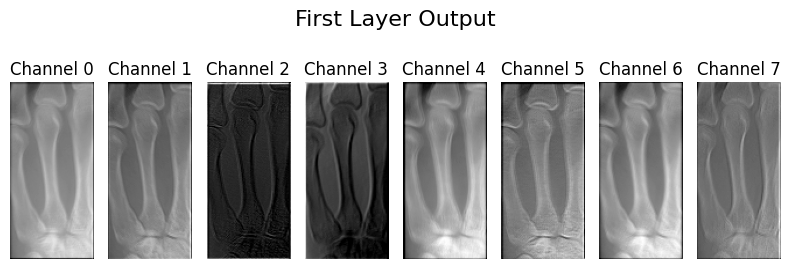

In [30]:
y_pred_UNet2.show_first_layer_outputs(images[0])

#### (c) Predict contours
- Use the trained U-Net classifiers to predict the bone contours for the image test set `I_test` and store the predictions in `y_pred_UNet1` and `y_pred_UNet2`. Plot your predictions, the input and ground truth using `plot_prediction_triplets`.

In [31]:
y_pred_UNet1 = [y_pred_UNet1.predict_segmentation(img) for img in I_test]# TODO: predict segmentation for y_pred_UNet1 on I_test
y_pred_UNet2 =  [y_pred_UNet2.predict_segmentation(img) for img in I_test]# TODO: predict segmentation for y_pred_UNet2 on I_test

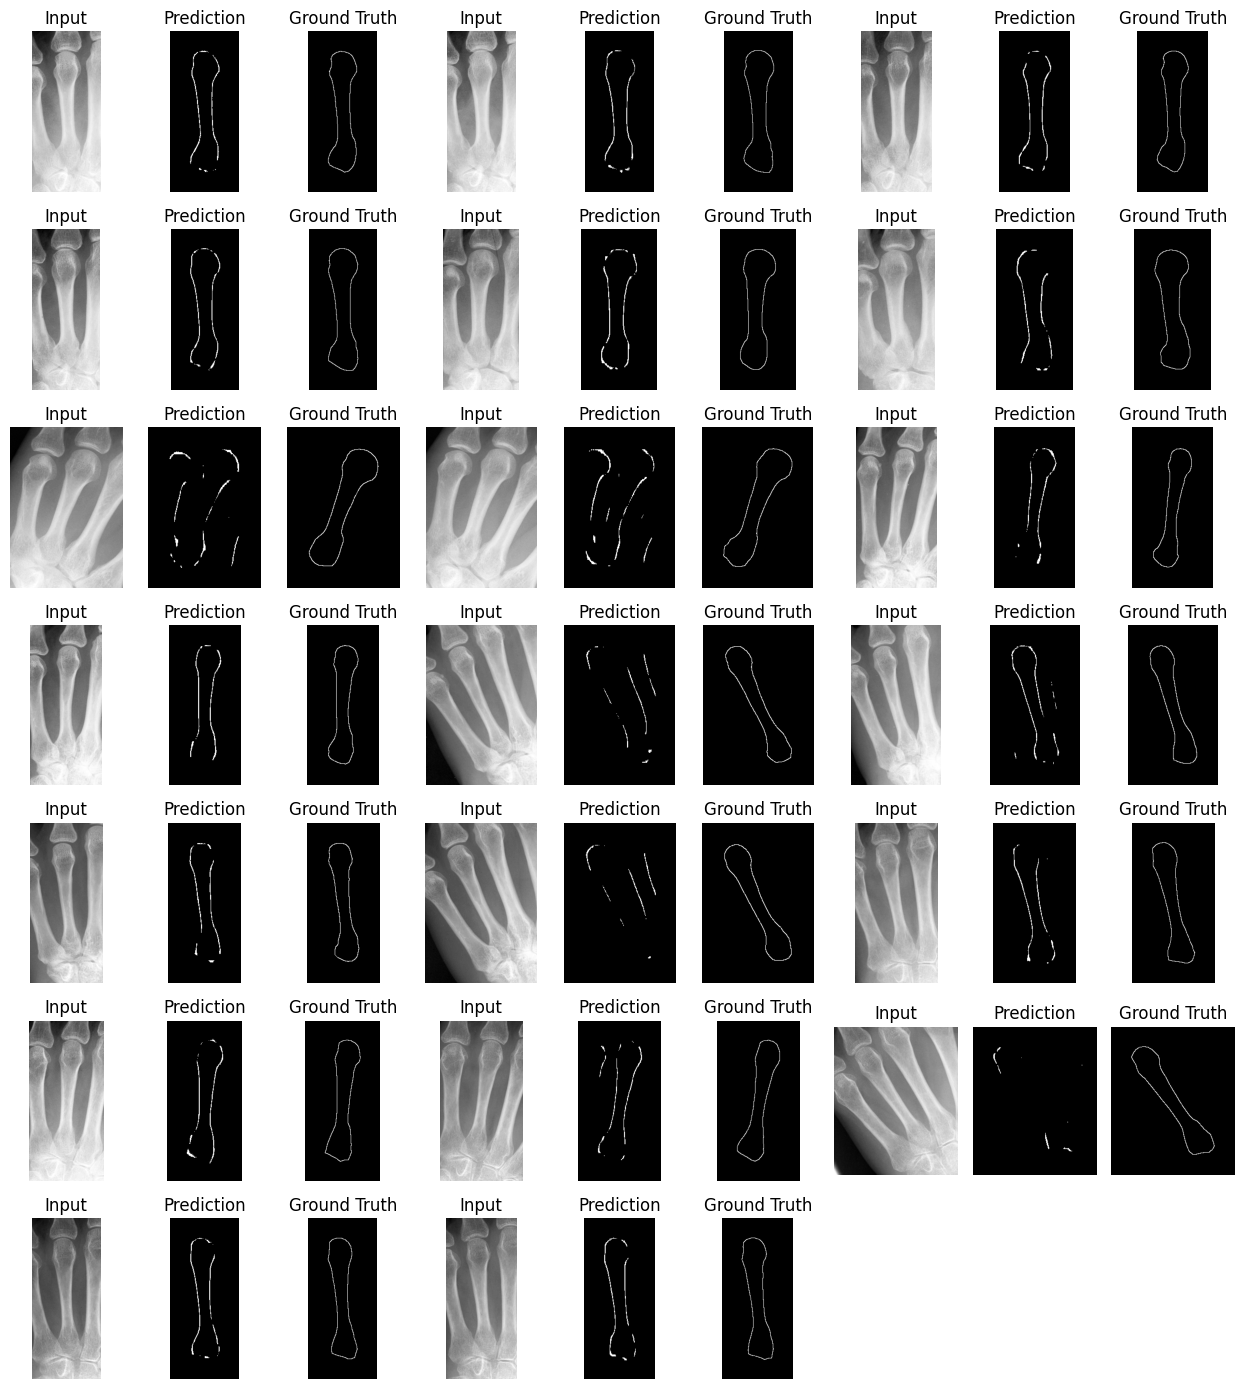

In [77]:
plot_prediction_triplets(I_test, y_pred_UNet1, y_test)

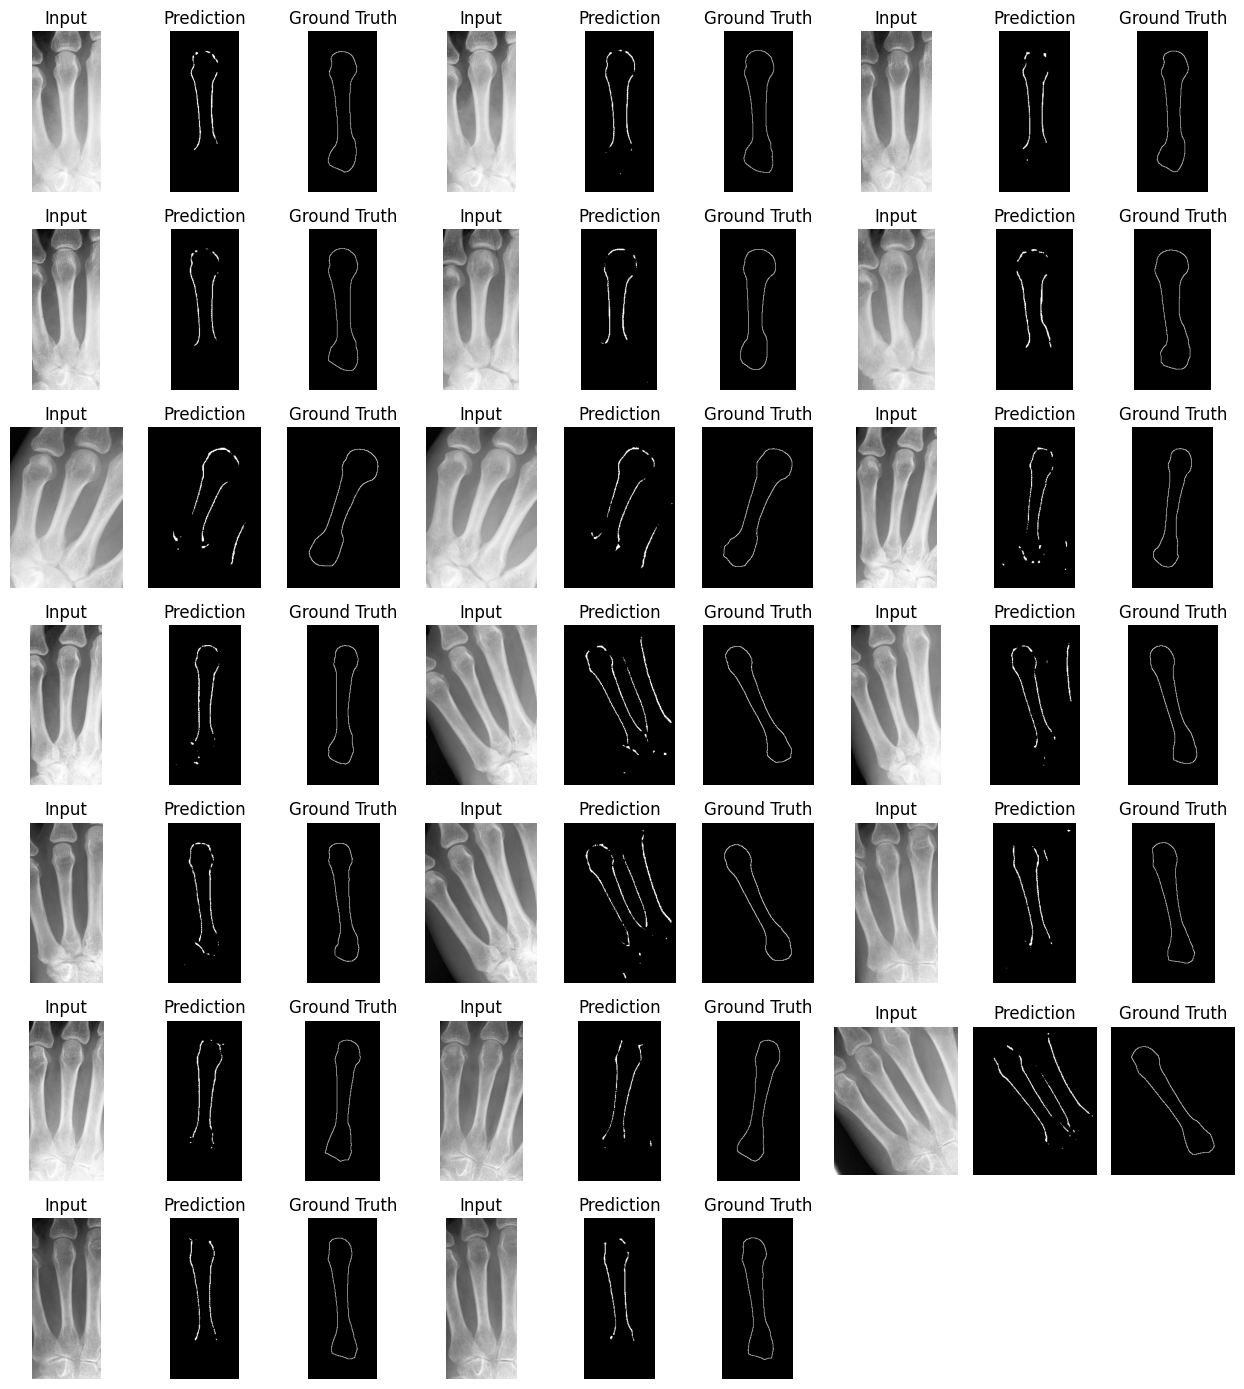

In [78]:
plot_prediction_triplets(I_test, y_pred_UNet2, y_test)

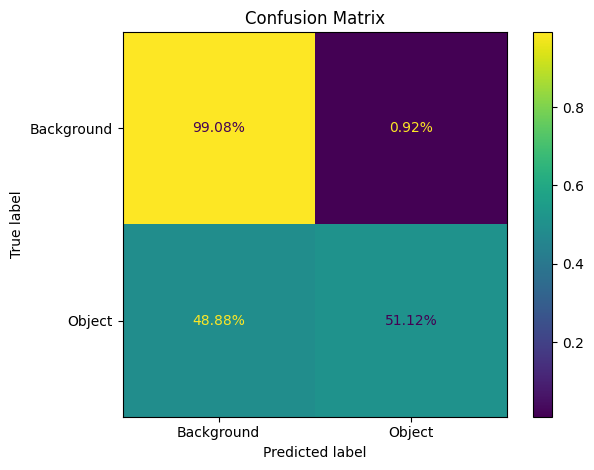

Dice Score: 0.45955767833039146
Precision: 0.4173896642776311
Recall: 0.5112035112035112


In [33]:
results_no_aug = evaluate_binary_segmentation(y_pred_UNet1, y_test)
print("Dice Score:", results_no_aug['dice'])
print("Precision:", results_no_aug['precision'])
print("Recall:", results_no_aug['recall'])

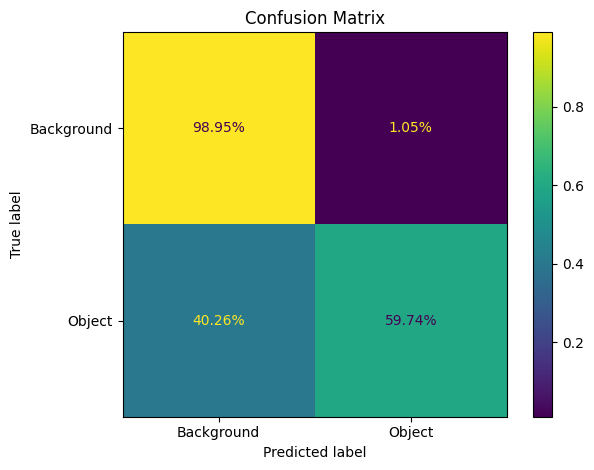

Dice Score: 0.49643302728814104
Precision: 0.4246387915936953
Recall: 0.5974435974435974


In [34]:
results_with_aug = evaluate_binary_segmentation(y_pred_UNet2, y_test)
print("Dice Score:", results_with_aug['dice'])
print("Precision:", results_with_aug['precision'])
print("Recall:", results_with_aug['recall'])

### 3.4. Shape Particle Filters (PF)
Shape particle filters are sequential Monte Carlo Methods used for solving a segmentation task. Therefore a shape model is required, which subsequently is fitted to the image to be segmented. For this task we will be using the PCA shape model of the first 30 images (created in Task 1.4 of this assignment) and create a fitting routine including the definition of a cost function used in the optimization process of the fitting. The shape model will be fitted to the output of the Random Forest segmentations.

#### (a) Implement `fit_shape_model` and `cost_function`
As the first step we formulate a function that models costs of fitting a shape to a target image. We are looking for a point in a parameter space (described by shape parameters, rotation, scaling, and translation) which describes an optimal fitted shape that segments the contours of a target object.
Implement the function `fit_shape_model` which should take a target image segmentation (in our case a predicted segmentation by the RF classifier in `y_pred_RF`) and the parameters _p_ of the shape model as input. The implemented function should fit the shape model to the  target segmentation.
- For running the optimization, use the helper function `optimize`, which takes a cost function (`cost_function`) and the upper and lower boundaries for the parameters to optimize.
- Implement the cost function which returns a scalar value that describes how well the (from _p_) generated shapes fits the classification result. (The better the shape fits the classification result, the lower the returned value). The cost function will be used by `fit_shape_model` in order to run the optimization for fitting the shape model to the segmentation.

Both `fit_shape_model` and `cost_function` will use `generate_shape` to generate shapes based on the shape parameters of the shape model and the transformation parameters used for scaling, rotation and translation.

In [ ]:
from scipy.ndimage import binary_closing, label as connected_components


_RF_GEOMETRY_CACHE = {}


def principal_axis(points_xy):
    """
    Return the centroid and main PCA axis of 2D points.

    Parameters
    ----------
    points_xy : ndarray, shape (N, 2)
        Points in [x, y] order.
    """
    points_xy = np.asarray(points_xy, dtype=float)

    if len(points_xy) < 2:
        return None, None

    center = np.mean(points_xy, axis=0)
    centered_points = points_xy - center

    covariance_matrix = np.cov(centered_points, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    axis = eigenvectors[:, np.argmax(eigenvalues)]

    axis_norm = np.linalg.norm(axis)

    if axis_norm < 1e-8:
        return center, None

    return center, axis / axis_norm


def get_rf_geometry(classification):
    """
    Calculate the centroid, principal axis and approximate length of the
    Random Forest segmentation.

    Results are cached because this geometry is constant during optimization.
    """
    cache_key = (id(classification), classification.shape)

    if cache_key in _RF_GEOMETRY_CACHE:
        return _RF_GEOMETRY_CACHE[cache_key]

    rf_mask = np.asarray(classification) > 0

    if not np.any(rf_mask):
        _RF_GEOMETRY_CACHE[cache_key] = None
        return None

    # Closing small gaps in the RF contour
    closed_mask = binary_closing(
        rf_mask,
        structure=np.ones((3, 3), dtype=bool),
        iterations=1,
    )

    # Removing very small isolated RF components
    component_map, number_components = connected_components(closed_mask)

    if number_components > 0:
        component_sizes = np.bincount(component_map.ravel())
        component_sizes[0] = 0  # ignoring the background

        largest_component_size = component_sizes.max()
        minimum_component_size = max(
            5,
            int(0.10 * largest_component_size),
        )

        labels_to_keep = np.flatnonzero(
            component_sizes >= minimum_component_size
        )

        cleaned_mask = np.isin(component_map, labels_to_keep)
    else:
        cleaned_mask = rf_mask

    if np.sum(cleaned_mask) < 2:
        cleaned_mask = rf_mask

    rf_points = np.column_stack(
        np.nonzero(cleaned_mask)
    )[:, ::-1].astype(float)

    rf_center, rf_axis = principal_axis(rf_points)

    if rf_center is None or rf_axis is None:
        _RF_GEOMETRY_CACHE[cache_key] = None
        return None

    # estimate the bone length along its principal axis
    projections = (rf_points - rf_center) @ rf_axis
    rf_length = max(float(np.ptp(projections)), 1.0)

    geometry = {
        "center": rf_center,
        "axis": rf_axis,
        "length": rf_length,
    }

    _RF_GEOMETRY_CACHE[cache_key] = geometry

    return geometry

In [ ]:
from scipy.ndimage import distance_transform_edt as edt

def cost_function(p, classification, eigen_vectors, mean_data):
    """
    Cost function between PCA-generated shape and a classification.

    Parameters
    ----------
    p : array_like
        Shape + transform parameters [b..., scale, rotation, x_t, y_t]
    classification : ndarray, shape (H, W)
        Segmentation mask (values in [0, 1])
    eigen_vectors : ndarray, shape (2N, d)
        PCA shape eigenvectors
    mean_data : ndarray, shape (2N,)
        Mean shape (flattened)

    Returns
    -------
    cost : float
        Fitting cost.
    """

    # TODO: get b, scale, rot, x_t, y_t from p and generate a shape using them
    
    # d fetches the number of PCA components used in the task 1.4
    d = eigen_vectors.shape[1]

    b        = p[:d]
    scale    = p[d]
    rotation = p[d + 1]
    x_t      = p[d + 2]
    y_t      = p[d + 3]

    shape = generate_shape(b, eigen_vectors, mean_data, scale, rotation, x_t, y_t)


    # TODO: calculate cost of fitting shape
    # Extract landmark coordinates
    N = len(shape) // 2
    x_landmarks = shape[:N]
    y_landmarks = shape[N:]

    shape_points = np.column_stack([
        x_landmarks,
        y_landmarks,
    ])

    # Create distance map from RF prediction
    contour_mask = classification > 0

    if not np.any(contour_mask):
        return 1e10

    distance_map = edt(~contour_mask)

    # Convert landmark coordinates to pixel indices
    x_int = np.round(x_landmarks).astype(int)
    y_int = np.round(y_landmarks).astype(int)

    H, W = classification.shape

    inside = (
        (x_int >= 0)
        & (x_int < W)
        & (y_int >= 0)
        & (y_int < H)
    )

    number_outside = int(np.sum(~inside))

    if not np.any(inside):
        return 1e10

    # Existing landmark-to-RF distance cost

    distances = distance_map[
        y_int[inside],
        x_int[inside],
    ]

    tau = 50.0
    robust_distances = np.minimum(distances, tau)
    data_cost = np.mean(robust_distances)

    # Penalizing unlikely PCA deformation
    shape_cost = np.sum(b ** 2)

    # Penalizing landmarks outside the image
    outside_cost = number_outside / N

   #centroid and orientation costs

    rf_geometry = get_rf_geometry(classification)
    shape_center, shape_axis = principal_axis(shape_points)

    if (
        rf_geometry is None
        or shape_center is None
        or shape_axis is None
    ):
        return 1e10

    rf_center = rf_geometry["center"]
    rf_axis = rf_geometry["axis"]
    rf_length = rf_geometry["length"]

    # Normalizing the center distance by bone length.
    center_distance = np.linalg.norm(
        shape_center - rf_center
    )

    center_cost = center_distance / rf_length

    # Comparing the principal axes
    # abs() is needed because axis and -axis describe the same line.
    axis_similarity = np.abs(
        np.dot(shape_axis, rf_axis)
    )

    axis_similarity = np.clip(
        axis_similarity,
        0.0,
        1.0,
    )

    angle_cost = 1.0 - axis_similarity ** 2


    alpha = 0.1   # PCA deformation
    beta = tau    # Outside-image penalty
    gamma = 15.0  # Center penalty
    delta = 25.0  # Angle penalty

    cost = (
        data_cost
        + alpha * shape_cost
        + beta * outside_cost
        + gamma * center_cost
        + delta * angle_cost
    )

    return cost

In [72]:
"""we're adding this cell to explore which optimization bounds 
make the most sense according to our data"""

train_landmarks = landmarks[:30]
train_aligned = aligned[:30]
train_images = images[:30]

heights = [img.shape[0] for img in train_images]
widths = [img.shape[1] for img in train_images]

print(
    f"\n The heights: {heights}, "
    f"\n The widths: {widths}"
)

# raw and aligned extrema
all_x = np.concatenate([lm[0] for lm in train_landmarks])
all_y = np.concatenate([lm[1] for lm in train_landmarks])

all_ax = train_aligned[:, 0, :].flatten()
all_ay = train_aligned[:, 1, :].flatten()

print(
    f"Raw landmarks x: "
    f"min={all_x.min():.2f}, "
    f"max={all_x.max():.2f}, "
    f"mean={all_x.mean():.2f}, "
    f"std={all_x.std():.2f}"
)

print(
    f"Raw landmarks y: "
    f"min={all_y.min():.2f}, "
    f"max={all_y.max():.2f}, "
    f"mean={all_y.mean():.2f}, "
    f"std={all_y.std():.2f}"
)

print(
    f"Aligned landmarks x: "
    f"min={all_ax.min():.3f}, "
    f"max={all_ax.max():.3f}, "
    f"mean={all_ax.mean():.3f}, "
    f"std={all_ax.std():.3f}"
)

print(
    f"Aligned landmarks y: "
    f"min={all_ay.min():.3f}, "
    f"max={all_ay.max():.3f}, "
    f"mean={all_ay.mean():.3f}, "
    f"std={all_ay.std():.3f}"
)

#translation

x_centers = np.array([lm[0].mean() for lm in train_landmarks])
y_centers = np.array([lm[1].mean() for lm in train_landmarks])

print(
    f"\nLandmark centroid x: min={x_centers.min():.1f}, "
    f"max={x_centers.max():.1f}, "
    f"mean={x_centers.mean():.1f}"
)

print(
    f"Landmark centroid y: min={y_centers.min():.1f}, "
    f"max={y_centers.max():.1f}, "
    f"mean={y_centers.mean():.1f}"
)

# typical scale: per-shape RMS distance from centroid
scales = []
for lm, aln in zip(landmarks, aligned):
    raw_x = lm[0] - lm[0].mean()
    raw_y = lm[1] - lm[1].mean()
    raw_rms = np.sqrt(np.mean(raw_x**2 + raw_y**2))

    aln_x = aln[0] - aln[0].mean()
    aln_y = aln[1] - aln[1].mean()
    aln_rms = np.sqrt(np.mean(aln_x**2 + aln_y**2))

    scales.append(raw_rms / aln_rms)

scales = np.array(scales)
print(f"\nPer-shape scale: min={scales.min():.4f}, max={scales.max():.4f}, mean={scales.mean():.4f}")





 The heights: [306, 300, 298, 302, 304, 303, 303, 297, 298, 300, 297, 302, 298, 300, 297, 302, 289, 296, 290, 299, 289, 298, 317, 314, 319, 313, 317, 315, 322, 319], 
 The widths: [143, 142, 154, 139, 138, 140, 135, 155, 133, 140, 143, 137, 137, 147, 137, 135, 136, 135, 143, 142, 143, 140, 161, 134, 143, 135, 144, 159, 136, 139]
Raw landmarks x: min=41.00, max=121.80, mean=71.59, std=18.70
Raw landmarks y: min=41.00, max=282.20, mean=153.98, std=71.90
Aligned landmarks x: min=-33.438, max=33.324, mean=-0.000, std=18.245
Aligned landmarks y: min=-124.026, max=116.721, mean=-0.000, std=71.649

Landmark centroid x: min=66.6, max=83.7, mean=71.6
Landmark centroid y: min=143.2, max=165.5, mean=154.0

Per-shape scale: min=1.0000, max=1.0000, mean=1.0000


In [73]:
def fit_shape_model(segmentation, eigen_vectors, eigen_values, mean_shape):
    """
    Fit a PCA-based shape model to a binary segmentation mask using global optimization.

    Parameters
    ----------
    segmentation : np.ndarray
        Binary segmentation mask (2D array with shape H×W).
    eigen_vectors : np.ndarray
        Matrix of eigenvectors from PCA, shape (2N, d), where N is number of shape points.
    eigen_values : np.ndarray
        1D array of eigenvalues from PCA, shape (d,).
    mean_shape : np.ndarray
        Mean shape vector, shape (2N,).

    Returns
    -------
    fitted_shape : np.ndarray
        Optimized shape vector in pixel coordinates, shape (2N,).
    best_params : np.ndarray
        Optimal parameters [b_opt, scale, rotation_deg, x_translation, y_translation], shape (d + 4,).
    """

    # TODO: Define bounds for optimization
    d = eigen_vectors.shape[1]
    b_upper = 3 * np.sqrt(eigen_values)
    b_lower = -b_upper
    scale_lower, scale_upper = 0.8, 1.2
    rot_lower,   rot_upper   = -60, 60
    margin=10
    x_lower, x_upper = 66.6 - margin, 83.7 + margin
    y_lower, y_upper = 143.2 - margin, 165.5+margin


    # TODO: concatenate the bounds for b, scale, rotation, x, and y into min_ and max_
    min_ = np.concatenate([b_lower, [scale_lower, rot_lower, x_lower, y_lower]])
    max_ = np.concatenate([b_upper, [scale_upper, rot_upper, x_upper, y_upper]])

    assert min_.shape == max_.shape == (d + 4,)

    def unified_cost_fn(p):
        return cost_function(p, segmentation, eigen_vectors, mean_shape)

    # optimize
    best_params = optimize(unified_cost_fn, min_, max_, random_state=0)

    # unpack optimal parameters
    b_opt      = best_params[:d]
    scale_opt  = best_params[d]
    rot_opt    = best_params[d + 1]
    x_t_opt    = best_params[d + 2]
    y_t_opt    = best_params[d + 3]

    # Reconstruct the final shape in image coordinates
    fitted_shape = generate_shape(
        b_opt,
        eigen_vectors,
        mean_shape,
        scale_opt,
        rot_opt,
        x_t_opt,
        y_t_opt
    )

    return fitted_shape, best_params

#### (b) Optimize for all test segmentations
- Optimize this function for all segmentations in `y_pred_RF` (20). We are using a stochastic optimization approach called Differential Evolution for this purpose.
- This method is very simple, robust and converges fast. We provide an implementation of this approach in optimize. An example to create and use a cost function for an optimization process can be found in `optimize_demo.py`. You can simply run it to get an example demonstration of the optimization.
- Visualize your results using the helper function plot_fitted_shapes. You may also plot the ground truth landmarks using this function.

In [74]:
from helper_functions import plot_fitted_shapes, optimize

In [75]:
fitted_shapes = [fit_shape_model(seg, eigen_vectors, eigen_values, mean_shape)[0] for seg in y_pred_RF]

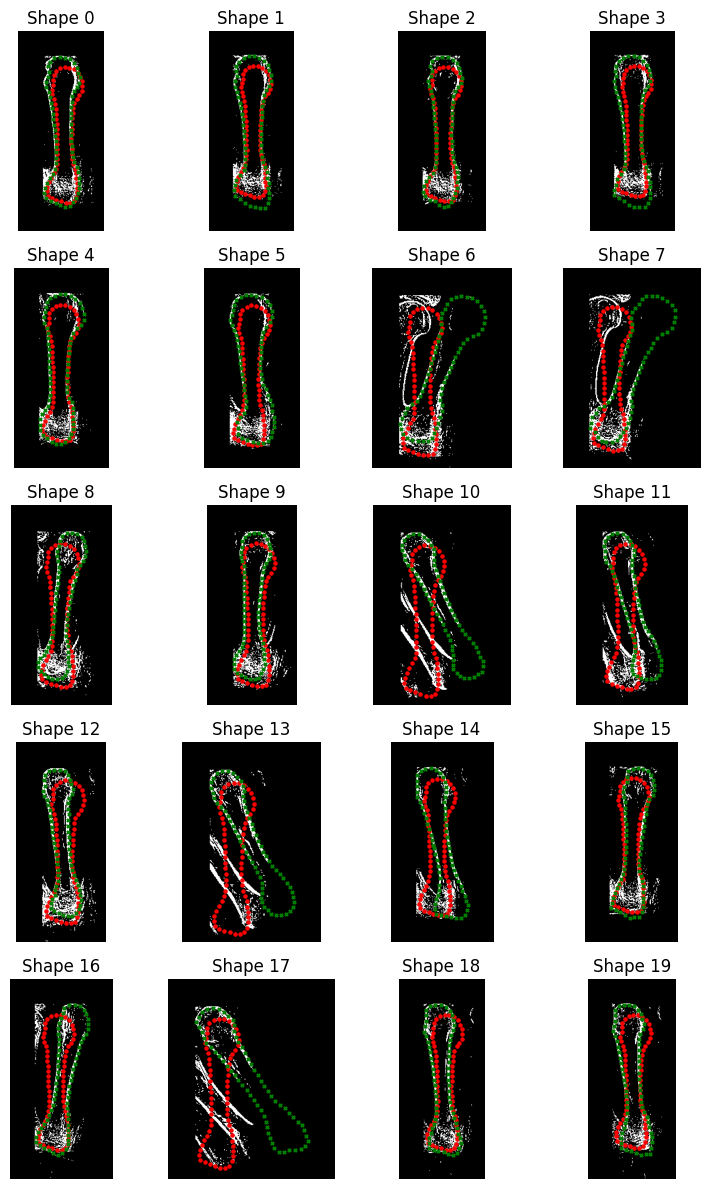

In [76]:
plot_fitted_shapes(fitted_shapes, y_pred_RF, gt_landmarks=landmarks[30:])